In [1]:
import tensorflow as tf
import numpy as np
import time, gc, os, json, warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score,
                             recall_score, f1_score)

2026-08-08 13:13:00.795873: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1786194781.024485      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1786194781.087153      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1786194781.597979      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786194781.598026      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1786194781.598029      58 computation_placer.cc:177] computation placer alr

✓ GPUs: 2
LOADING MNIST DATASET
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28, 1) | Test: (10000, 28, 28, 1)
Train: (52500, 28, 28, 1) | Val: (7500, 28, 28, 1) | Test: (10000, 28, 28, 1)
NS-LSO: Multi-Objective CNN Optimization — MNIST

GENERATION 1/5


I0000 00:00:1786194798.957064      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1786194798.963278      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1786194807.286030     129 service.cc:152] XLA service 0x797130017120 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1786194807.286070     129 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1786194807.286075     129 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1786194808.186645     129 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1786194819.120150     129 device_compiler.h:188] Compiled clust

  Lion  1/20: acc=0.9933 | inf=4.87ms | size=4.84MB
  Lion  2/20: acc=0.9936 | inf=7.41ms | size=11.44MB
  Lion  3/20: acc=0.9855 | inf=7.46ms | size=11.86MB
  Lion  4/20: acc=0.9791 | inf=14.19ms | size=0.98MB
  Lion  5/20: acc=0.9541 | inf=21.36ms | size=0.30MB
  Lion  6/20: acc=0.9783 | inf=17.82ms | size=0.84MB
  Lion  7/20: acc=0.9937 | inf=5.85ms | size=8.76MB
  Lion  8/20: acc=0.9509 | inf=9.50ms | size=0.53MB
  Lion  9/20: acc=0.9883 | inf=14.25ms | size=1.82MB
  Lion 10/20: acc=0.9927 | inf=7.15ms | size=8.16MB
  Lion 11/20: acc=0.9343 | inf=13.54ms | size=0.68MB
  Lion 12/20: acc=0.9940 | inf=4.86ms | size=5.16MB
  Lion 13/20: acc=0.9880 | inf=17.80ms | size=1.50MB
  Lion 14/20: acc=0.9947 | inf=4.31ms | size=6.97MB
  Lion 15/20: acc=0.9919 | inf=6.04ms | size=9.05MB
  Lion 16/20: acc=0.8613 | inf=14.22ms | size=0.36MB
  Lion 17/20: acc=0.9945 | inf=4.98ms | size=4.68MB
  Lion 18/20: acc=0.9648 | inf=12.66ms | size=1.78MB
  Lion 19/20: acc=0.9888 | inf=5.44ms | size=9.56MB
  

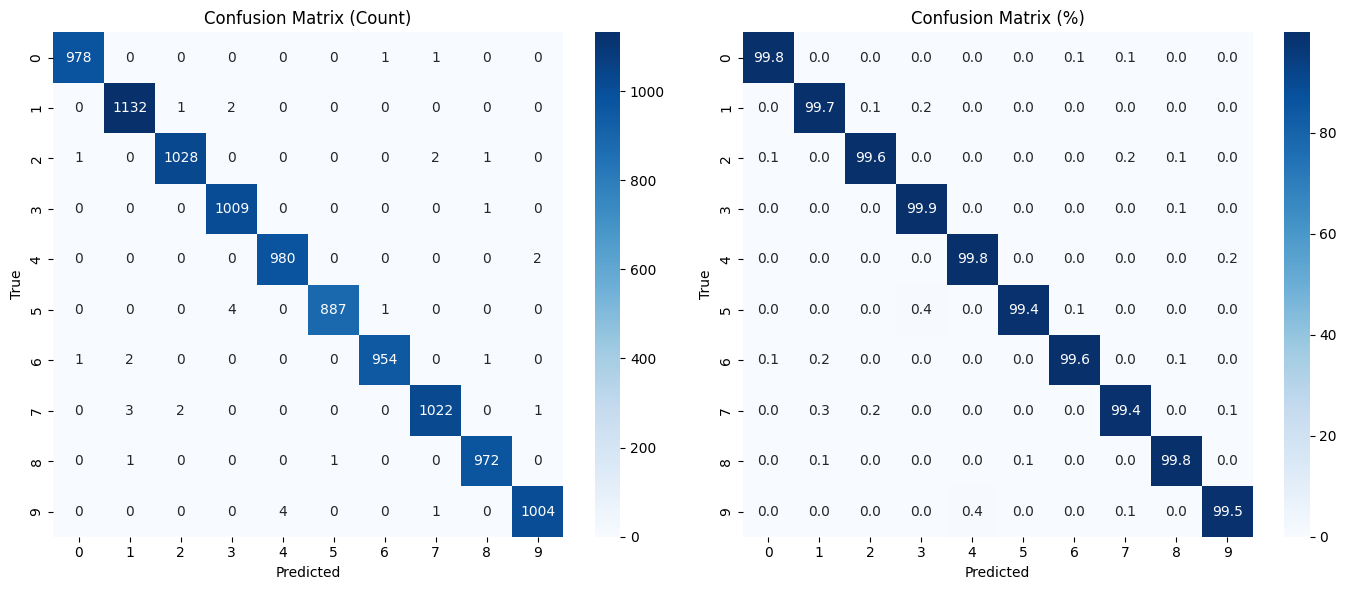

[✓] Training history saved


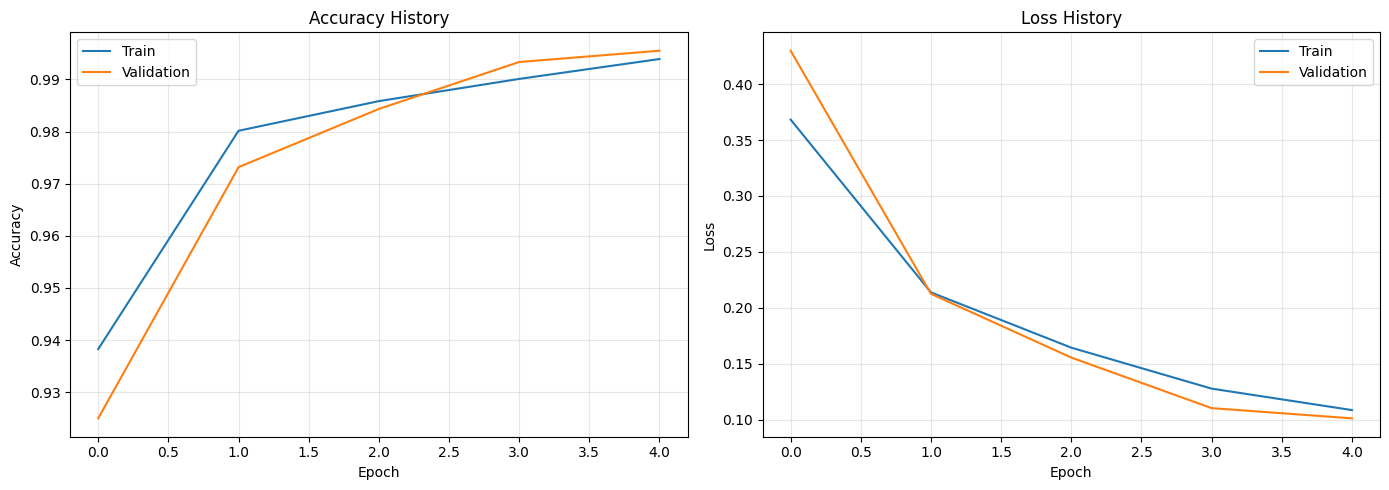

[✓] Pareto front saved


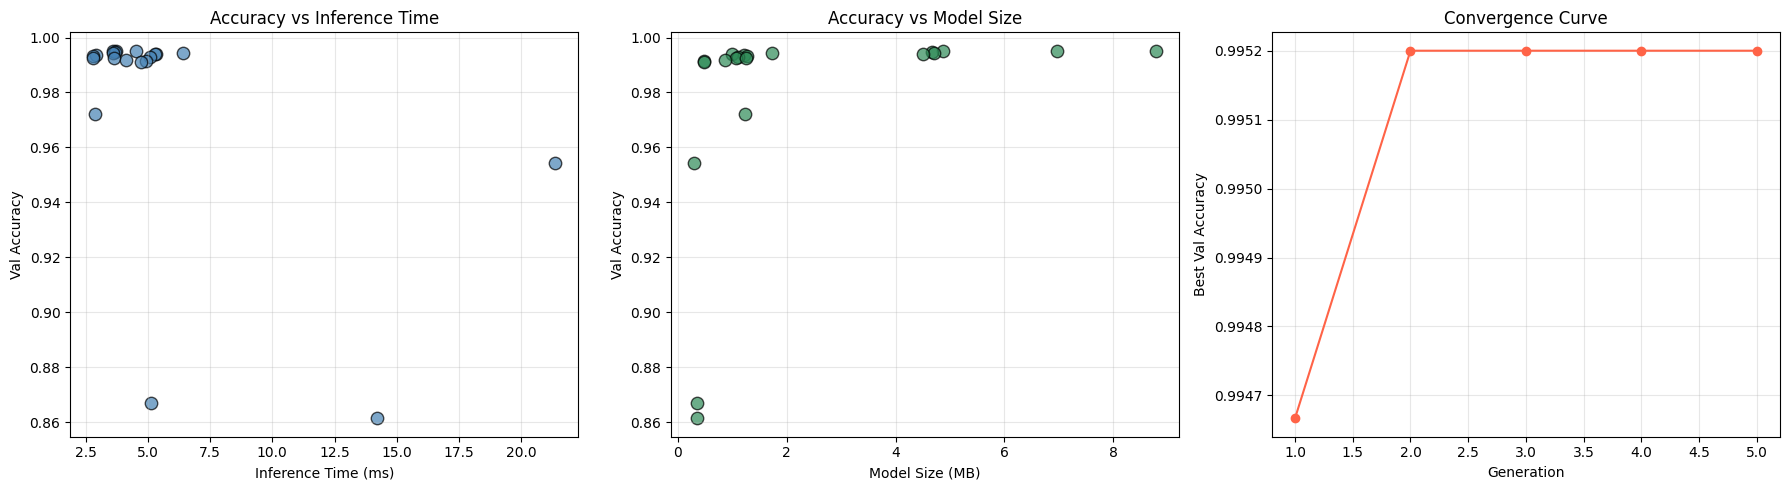

[✓] All results saved: /kaggle/working/mnist_nslso_results.json

NS-LSO MNIST COMPLETED


In [2]:
warnings.filterwarnings('ignore')

# ---------- GPU CONFIG ----------
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPUs: {len(gpus)}")
else:
    print("⚠ No GPU - using CPU")
tf.keras.mixed_precision.set_global_policy('float32')

# ---------- LOAD MNIST ----------
print("="*60); print("LOADING MNIST DATASET"); print("="*60)
(x_train_full, y_train_full), (x_test_full, y_test_full) = \
    tf.keras.datasets.mnist.load_data()

x_train_full = x_train_full.astype('float32') / 255.0
x_test_full  = x_test_full.astype('float32')  / 255.0
x_train_full = x_train_full[..., np.newaxis]   # (60000, 28, 28, 1)
x_test_full  = x_test_full[..., np.newaxis]    # (10000, 28, 28, 1)
y_train_full = y_train_full.flatten().astype('int32')
y_test_full  = y_test_full.flatten().astype('int32')
print(f"Train: {x_train_full.shape} | Test: {x_test_full.shape}")


# ---------- DATA SUBSET ----------
def prepare_subset(x_train, y_train, x_test, y_test,
                   train_size=52500, val_size=7500, seed=42):
    """Val diambil dari training — tidak menyentuh test set."""
    rng   = np.random.default_rng(seed)
    total = min(train_size + val_size, len(x_train))
    perm  = rng.permutation(len(x_train))[:total]
    x_tr  = x_train[perm[:train_size]];  y_tr  = y_train[perm[:train_size]]
    x_val = x_train[perm[train_size:]];  y_val = y_train[perm[train_size:]]
    return (x_tr, y_tr), (x_val, y_val), (x_test.copy(), y_test.copy())

(x_train, y_train), (x_val, y_val), (x_test, y_test) = prepare_subset(
    x_train_full, y_train_full, x_test_full, y_test_full
)
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")


# ---------- AUGMENTATION PIPELINE ----------
@tf.function
def augment(image, label):
   
    # Padding 2px + random crop → simulasi translasi ±2px
    image = tf.pad(image, [[2, 2], [2, 2], [0, 0]], mode='CONSTANT')
    image = tf.image.random_crop(image, size=[28, 28, 1])
    # Brightness ringan (max_delta=0.05 agar tidak mengubah struktur angka)
    image = tf.image.random_brightness(image, max_delta=0.05)
    return tf.clip_by_value(image, 0.0, 1.0), label

def make_dataset(x, y, batch_size, augment_data=False, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((x, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(x), seed=42)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ---------- CNN BUILDER ----------
def build_cnn_model(hp: dict, num_classes=10):
    """
    FIX: num_layers max 4 untuk MNIST 28×28.
    Resolusi: 28 → 14 → 7 → 4 → 2 (layer ke-5 → 1×1, tidak berguna)
    """
    num_layers   = int(np.clip(hp['num_layers'],   2, 4))   # FIX: max 4
    filters_base = int(np.clip(hp['filters_base'], 16, 128))
    dropout_rate = float(np.clip(hp['dropout_rate'], 0.0, 0.5))
    dense_units  = int(np.clip(hp['dense_units'],  32, 512))
    use_residual  = int(hp.get('use_residual',  0)) == 1
    use_separable = int(hp.get('use_separable', 0)) == 1

    inputs = tf.keras.Input(shape=(28, 28, 1))
    x = inputs

    for i in range(num_layers):
        filters  = min(filters_base * (2 ** i), 256)
        shortcut = x

        # Conv block 1
        if use_separable:
            x = tf.keras.layers.SeparableConv2D(
                    filters, 3, padding='same', use_bias=False,
                    depthwise_regularizer=tf.keras.regularizers.l2(1e-4),
                    pointwise_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        else:
            x = tf.keras.layers.Conv2D(
                    filters, 3, padding='same', use_bias=False,
                    kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

        # Conv block 2
        if use_separable:
            x = tf.keras.layers.SeparableConv2D(
                    filters, 3, padding='same', use_bias=False,
                    depthwise_regularizer=tf.keras.regularizers.l2(1e-4),
                    pointwise_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        else:
            x = tf.keras.layers.Conv2D(
                    filters, 3, padding='same', use_bias=False,
                    kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

        # Residual connection
        if use_residual:
            if shortcut.shape[-1] != filters:
                shortcut = tf.keras.layers.Conv2D(
                    filters, 1, padding='same', use_bias=False)(shortcut)
                shortcut = tf.keras.layers.BatchNormalization()(shortcut)
            x = tf.keras.layers.add([x, shortcut])

        x = tf.keras.layers.MaxPooling2D(2, padding='same')(x)
        x = tf.keras.layers.Dropout(dropout_rate)(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(dense_units, use_bias=False,
                               kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Activation('relu')(x)
    x = tf.keras.layers.Dropout(dropout_rate)(x)
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

    return tf.keras.Model(inputs, outputs)


# ---------- COSINE DECAY CALLBACK ----------
class CosineDecayCallback(tf.keras.callbacks.Callback):
    def __init__(self, lr_start, total_steps):
        super().__init__()
        self.lr_start = lr_start; self.total_steps = total_steps; self.step = 0

    def on_train_batch_end(self, batch, logs=None):
        self.step += 1
        frac   = self.step / self.total_steps
        new_lr = max(self.lr_start * 0.5 * (1 + np.cos(np.pi * frac)), 1e-6)
        self.model.optimizer.learning_rate.assign(new_lr)


# ---------- EVALUATION FUNCTION ----------
def evaluate_multi(lion, x_train, y_train, x_val, y_val,
                   epochs=5, verbose=0):
    hp         = lion.hyperparameters
    batch_size = int(np.clip(hp['batch_size'], 32, 256))
    model      = build_cnn_model(hp)
    initial_lr = float(hp['learning_rate'])

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    steps_per_epoch = max(1, len(x_train) // batch_size)
    total_steps     = steps_per_epoch * epochs
    train_ds = make_dataset(x_train, y_train, batch_size, augment_data=True)
    val_ds   = make_dataset(x_val,   y_val,   batch_size, augment_data=False, shuffle=False)

    try:
        t0 = time.time()
        history = model.fit(
            train_ds, epochs=epochs, validation_data=val_ds,
            callbacks=[
                tf.keras.callbacks.EarlyStopping(
                    monitor='val_accuracy', patience=5,
                    restore_best_weights=True, verbose=0),
                CosineDecayCallback(lr_start=initial_lr, total_steps=total_steps)
            ],
            verbose=verbose
        )
        train_time = time.time() - t0
        val_acc = max(history.history['val_accuracy'])
    except Exception as e:
        print(f"    ⚠ Training error: {e}")
        del model; gc.collect(); tf.keras.backend.clear_session()
        return {'accuracy':0.0,'inference_time':999.0,'model_size':999.0,'train_time':0.0}

    n_inf   = min(500, len(x_val))
    inf_idx = np.random.choice(len(x_val), n_inf, replace=False)
    t1 = time.time()
    model.predict(x_val[inf_idx], verbose=0)
    inf_time = (time.time() - t1) / n_inf * 1000

    model_size = model.count_params() * 4 / (1024**2)
    del model; gc.collect(); tf.keras.backend.clear_session()

    return {'accuracy':float(val_acc), 'inference_time':float(inf_time),
            'model_size':float(model_size), 'train_time':float(train_time)}


# ---------- NORMALISASI & DOMINANCE ----------
GLOBAL_NORM_BOUNDS = {
    'accuracy':       (0.0,   1.0),
    'inference_time': (0.0, 200.0),
    'model_size':     (0.0, 500.0),
}

def normalize_objectives(pop_fit):
    if not pop_fit: return pop_fit
    for p in pop_fit:
        for k in ['accuracy','inference_time','model_size']:
            mn, mx = GLOBAL_NORM_BOUNDS[k]
            raw = float(np.clip(p[k], mn, mx))
            p[k+'_norm'] = (raw-mn)/(mx-mn) if mx!=mn else 0.5
    return pop_fit

def dominates(a, b):
    av = (-a['accuracy_norm'], a['inference_time_norm'], a['model_size_norm'])
    bv = (-b['accuracy_norm'], b['inference_time_norm'], b['model_size_norm'])
    return all(x<=y for x,y in zip(av,bv)) and any(x<y for x,y in zip(av,bv))

def fast_non_dominated_sort(pop):
    if not pop: return []
    n = len(pop)
    dc = [0]*n; dl = [[] for _ in range(n)]; fronts = [[]]
    for i in range(n):
        for j in range(n):
            if i==j: continue
            if dominates(pop[i],pop[j]):   dl[i].append(j)
            elif dominates(pop[j],pop[i]): dc[i]+=1
        if dc[i]==0: fronts[0].append(i)
    i=0
    while i<len(fronts) and fronts[i]:
        nf=[]
        for idx in fronts[i]:
            for j in dl[idx]:
                dc[j]-=1
                if dc[j]==0: nf.append(j)
        if nf: fronts.append(nf)
        i+=1
    return [[pop[idx] for idx in f] for f in fronts if f]

def crowding_distance(front):
    n=len(front)
    if n<=2: return [float('inf')]*n
    dists=[0.0]*n
    for obj in ['accuracy_norm','inference_time_norm','model_size_norm']:
        sidx=sorted(range(n), key=lambda x: front[x][obj])
        dists[sidx[0]]=dists[sidx[-1]]=float('inf')
        span=front[sidx[-1]][obj]-front[sidx[0]][obj]
        if span==0: continue
        for k in range(1,n-1):
            dists[sidx[k]]+=(front[sidx[k+1]][obj]-front[sidx[k-1]][obj])/span
    return dists


# ---------- CLASS LION ----------
class Lion:
    def __init__(self, hyperparameters):
        self.hyperparameters = hyperparameters.copy()


# ---------- NS-LSO OPTIMIZER ----------
class NSLSO_Optimizer:
    def __init__(self, population_size=20, max_generations=5, hp_range=None):
        self.pop_size = population_size
        self.max_gen  = max_generations
        self.hp_range = hp_range or {
            'learning_rate': (1e-4, 5e-3),
            'batch_size':    (32,  256),
            'num_layers':    (2,   4),    # FIX: max 4 untuk MNIST
            'filters_base':  (16,  128),
            'dropout_rate':  (0.1, 0.5),
            'dense_units':   (64,  512),
            'use_residual':  (0,   1),
            'use_separable': (0,   1)
        }
        self.swarm=[]; self.archive=[]; self.history=[]

    def initialize(self):
        rng=np.random.default_rng(42); self.swarm=[]
        for _ in range(self.pop_size):
            hp={}
            for param,(low,high) in self.hp_range.items():
                if param=='learning_rate':
                    hp[param]=float(10**rng.uniform(np.log10(low),np.log10(high)))
                elif param in ['num_layers','batch_size','filters_base','dense_units',
                               'use_residual','use_separable']:
                    hp[param]=int(rng.integers(low,high+1))
                else:
                    hp[param]=float(rng.uniform(low,high))
            hp['momentum_lr']=0.0; hp['last_acc']=0.0
            self.swarm.append(Lion(hp))

    def lion_update(self, lion, archive, beta=0.9, eta=0.1):
        hp=lion.hyperparameters.copy()
        mean_acc=np.mean([p['accuracy'] for p in archive]) if archive else 0.5
        grad=(hp.get('last_acc',0.5)-mean_acc)/(mean_acc+1e-8)
        mom=beta*hp.get('momentum_lr',0.0)+(1-beta)*grad
        hp['momentum_lr']=float(mom)
        hp['learning_rate']=float(np.clip(
            hp['learning_rate']*(1+eta*np.sign(mom+1e-8)),1e-5,1e-2))

        if np.random.rand()<0.3:
            hp['num_layers']=int(np.clip(  # FIX: max 4
                hp['num_layers']+np.random.choice([-1,1]),2,4))

        for param in ['filters_base','dense_units']:
            if np.random.rand()<0.3:
                low,high=self.hp_range[param]
                hp[param]=int(np.clip(int(hp[param]*np.random.uniform(0.85,1.15)),low,high))

        if np.random.rand()<0.3:
            choices=[32,64,128,256]
            idx=min(range(len(choices)),key=lambda x: abs(choices[x]-int(hp['batch_size'])))
            hp['batch_size']=choices[int(np.clip(idx+np.random.choice([-1,1]),0,len(choices)-1))]

        if np.random.rand()<0.3:
            hp['dropout_rate']=float(np.clip(
                hp['dropout_rate']+np.random.normal(0,0.05),0.0,0.5))

        if np.random.rand()<0.2: hp['use_residual'] =1-int(hp.get('use_residual', 0))
        if np.random.rand()<0.2: hp['use_separable']=1-int(hp.get('use_separable',0))

        return Lion(hp)

    def optimize(self, x_train, y_train, x_val, y_val,
                 epochs_per_eval=5, verbose=1):
        self.initialize()
        for gen in range(1, self.max_gen+1):
            if verbose:
                print(f"\n{'='*60}"); print(f"GENERATION {gen}/{self.max_gen}"); print(f"{'='*60}")

            pop_fit=[]
            for i,lion in enumerate(self.swarm):
                fit=evaluate_multi(lion,x_train,y_train,x_val,y_val,
                                   epochs=epochs_per_eval,verbose=0)
                lion.hyperparameters['last_acc']=fit['accuracy']

                if fit['accuracy']<0.15:
                    if verbose: print(f"  Lion {i+1:2d}: FAILED (acc={fit['accuracy']:.4f})")
                    continue

                fit['hyperparams']={k:v for k,v in lion.hyperparameters.items()
                                    if not k.startswith('momentum') and k!='last_acc'}
                pop_fit.append(fit)
                if verbose:
                    print(f"  Lion {i+1:2d}/{self.pop_size}: "
                          f"acc={fit['accuracy']:.4f} | "
                          f"inf={fit['inference_time']:.2f}ms | "
                          f"size={fit['model_size']:.2f}MB")

            if not pop_fit:
                print("  ⚠ All failed! Using backup...")
                fit=evaluate_multi(self.swarm[0],x_train,y_train,x_val,y_val,epochs=15)
                fit['hyperparams']={k:v for k,v in self.swarm[0].hyperparameters.items()
                                    if not k.startswith('momentum') and k!='last_acc'}
                fit['accuracy']=max(fit['accuracy'],0.15); pop_fit.append(fit)

            pop_fit      =normalize_objectives(pop_fit)
            self.archive =normalize_objectives(self.archive)
            fronts       =fast_non_dominated_sort(pop_fit+self.archive)

            new_archive=[]
            for front in fronts:
                if len(new_archive)+len(front)<=self.pop_size:
                    new_archive.extend(front)
                else:
                    cd=crowding_distance(front)
                    ranked=sorted(zip(cd,front),key=lambda x:x[0],reverse=True)
                    new_archive.extend(s for _,s in ranked[:self.pop_size-len(new_archive)])
                    break
            self.archive=new_archive

            front_0=fronts[0] if fronts else []
            print(f"\n  >>> FRONT-0: {len(front_0)} solutions <<<")
            for sol in front_0[:3]:
                print(f"      acc={sol['accuracy']:.4f} | "
                      f"inf={sol['inference_time']:.2f}ms | "
                      f"size={sol['model_size']:.2f}MB")

            self.swarm=[self.lion_update(lion,self.archive) for lion in self.swarm]
            self.history.append({'generation':gen,'front_0_size':len(front_0),
                                 'archive_size':len(self.archive),
                                 'best_acc':max((s['accuracy'] for s in self.archive),default=0.0)})
            if gen%2==0: self._save_checkpoint(f'/kaggle/working/nslso_checkpoint_gen{gen}.json')

        return self.archive

    def _save_checkpoint(self, path):
        def _cast(v):
            if isinstance(v,(np.floating,float)): return float(v)
            if isinstance(v,(np.integer,int)):     return int(v)
            if isinstance(v,np.ndarray):           return v.tolist()
            return v
        with open(path,'w') as f:
            json.dump({'archive':[{k:_cast(v) for k,v in s.items() if k!='hyperparams'}
                                  for s in self.archive],'history':self.history},f,indent=2)
        print(f"  [✓] Checkpoint saved: {path}")


# ---------- FINAL EVALUATION ----------
def final_test_evaluation(best_hp, x_train_full, y_train_full,
                          x_test, y_test, epochs=50):
    rng=np.random.default_rng(99); n=len(x_train_full)
    perm=rng.permutation(n); cut=int(n*0.9)
    x_tr=x_train_full[perm[:cut]];   y_tr=y_train_full[perm[:cut]]
    x_vl=x_train_full[perm[cut:]];   y_vl=y_train_full[perm[cut:]]

    batch_size=int(np.clip(best_hp['batch_size'],32,256))
    model=build_cnn_model(best_hp)
    initial_lr=float(best_hp['learning_rate'])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=initial_lr),
                  loss='sparse_categorical_crossentropy',metrics=['accuracy'])

    steps_total=max(1,len(x_tr)//batch_size)*epochs
    train_ds=make_dataset(x_tr,y_tr,batch_size,augment_data=True)
    val_ds  =make_dataset(x_vl,y_vl,batch_size,augment_data=False,shuffle=False)

    print(f"\nTraining final model ({epochs} epochs)...")
    history=model.fit(
        train_ds,epochs=epochs,validation_data=val_ds,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(
                monitor='val_accuracy',patience=10,
                restore_best_weights=True,verbose=1),
            CosineDecayCallback(lr_start=initial_lr,total_steps=steps_total)
        ],verbose=1
    )

    # Prediksi di test set
    test_ds     =make_dataset(x_test,y_test,batch_size,augment_data=False,shuffle=False)
    y_pred_probs=model.predict(test_ds,verbose=0)
    y_pred      =np.argmax(y_pred_probs,axis=1)

    # Semua metrik
    accuracy          =accuracy_score(y_test,y_pred)
    precision_pc      =precision_score(y_test,y_pred,average=None,zero_division=0)
    recall_pc         =recall_score(y_test,y_pred,average=None,zero_division=0)
    f1_pc             =f1_score(y_test,y_pred,average=None,zero_division=0)
    precision_macro   =float(np.mean(precision_pc))
    recall_macro      =float(np.mean(recall_pc))
    f1_macro          =float(np.mean(f1_pc))
    precision_weighted=float(precision_score(y_test,y_pred,average='weighted',zero_division=0))
    recall_weighted   =float(recall_score(y_test,y_pred,average='weighted',zero_division=0))
    f1_weighted       =float(f1_score(y_test,y_pred,average='weighted',zero_division=0))

    cm    =confusion_matrix(y_test,y_pred)
    cm_pct=cm/cm.sum(axis=1,keepdims=True)*100

    model_size  =model.count_params()*4/(1024**2)
    total_params=model.count_params()

    n_inf=min(500,len(x_test)); inf_idx=np.random.choice(len(x_test),n_inf,replace=False)
    t1=time.time(); model.predict(x_test[inf_idx],verbose=0)
    inf_time=(time.time()-t1)/n_inf*1000

    model.save('/kaggle/working/best_mnist_model.keras')
    print("[✓] Model saved: /kaggle/working/best_mnist_model.keras")

    del model; gc.collect(); tf.keras.backend.clear_session()
    return {
        'accuracy':accuracy,
        'precision_per_class':precision_pc.tolist(),
        'recall_per_class':recall_pc.tolist(),
        'f1_per_class':f1_pc.tolist(),
        'precision_macro':precision_macro,'recall_macro':recall_macro,'f1_macro':f1_macro,
        'precision_weighted':precision_weighted,'recall_weighted':recall_weighted,'f1_weighted':f1_weighted,
        'confusion_matrix':cm.tolist(),'confusion_matrix_percent':cm_pct.tolist(),
        'inference_time_ms':float(inf_time),'model_size_mb':float(model_size),
        'total_params':int(total_params),'y_pred':y_pred.tolist()
    }, history


# ---------- MAIN ----------
def main():
    print("NS-LSO: Multi-Objective CNN Optimization — MNIST")
   

    nslso=NSLSO_Optimizer(
        population_size=20,max_generations=5,
        hp_range={
            'learning_rate':(1e-4,5e-3),
            'batch_size'   :(32,256),
            'num_layers'   :(2,4),     # FIX: max 4
            'filters_base' :(16,128),
            'dropout_rate' :(0.1,0.5),
            'dense_units'  :(64,512),
            'use_residual' :(0,1),
            'use_separable':(0,1)
        }
    )

    start=time.time()
    pareto_front=nslso.optimize(x_train,y_train,x_val,y_val,
                                epochs_per_eval=5,verbose=1)
    total_time=time.time()-start

    print("\n"+"="*60); print("FINAL RESULTS"); print("="*60)
    print(f"Total time   : {total_time/3600:.2f} hours")
    print(f"Pareto-front : {len(pareto_front)} solutions")

    pareto_front.sort(key=lambda x: x['accuracy'],reverse=True)
    print("\n--- TOP 5 PARETO SOLUTIONS ---")
    for i,sol in enumerate(pareto_front[:5],1):
        hp=sol['hyperparams']
        print(f"\n  Solution {i}: acc={sol['accuracy']:.4f} | "
              f"inf={sol['inference_time']:.2f}ms | size={sol['model_size']:.2f}MB")
        print(f"    lr={hp['learning_rate']:.5f}, layers={hp['num_layers']}, "
              f"filters={hp['filters_base']}, batch={hp['batch_size']}, "
              f"dense={hp['dense_units']}, dropout={hp['dropout_rate']:.2f}, "
              f"residual={hp['use_residual']}, separable={hp['use_separable']}")

    # Final evaluation
    print("\n"+"="*60); print("FINAL EVALUATION ON TEST SET"); print("="*60)
    best_hp=pareto_front[0]['hyperparams']
    print(f"\nBest solution val acc : {pareto_front[0]['accuracy']:.4f}")

    results, history = final_test_evaluation(
        best_hp, x_train_full, y_train_full, x_test_full, y_test_full, epochs=5
    )

    # Print semua metrik
    print("\n"+"="*60); print("TEST SET METRICS"); print("="*60)
    print(f"\n  Accuracy           : {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
    print(f"  Precision (macro)  : {results['precision_macro']:.4f}")
    print(f"  Recall (macro)     : {results['recall_macro']:.4f}")
    print(f"  F1-score (macro)   : {results['f1_macro']:.4f}")
    print(f"  Precision (weighted): {results['precision_weighted']:.4f}")
    print(f"  Recall (weighted)  : {results['recall_weighted']:.4f}")
    print(f"  F1 (weighted)      : {results['f1_weighted']:.4f}")

    print("\n  --- Per-class metrics ---")
    print(f"  {'Digit':<7} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print("  " + "-"*37)
    for i in range(10):
        print(f"  {i:<7}  {results['precision_per_class'][i]:.4f}   "
              f"{results['recall_per_class'][i]:.4f}   {results['f1_per_class'][i]:.4f}")

    print(f"\n  Inference time : {results['inference_time_ms']:.3f} ms/gambar")
    print(f"  Model size     : {results['model_size_mb']:.2f} MB")
    print(f"  Total params   : {results['total_params']:,}")

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    cm    = np.array(results['confusion_matrix'])
    cm_pct= np.array(results['confusion_matrix_percent'])
    sns.heatmap(cm,    annot=True, fmt='d',   cmap='Blues',
                xticklabels=range(10),yticklabels=range(10),ax=axes[0])
    axes[0].set_title('Confusion Matrix (Count)')
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    sns.heatmap(cm_pct,annot=True, fmt='.1f', cmap='Blues',
                xticklabels=range(10),yticklabels=range(10),ax=axes[1])
    axes[1].set_title('Confusion Matrix (%)')
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    plt.tight_layout()
    plt.savefig('/kaggle/working/mnist_confusion_matrices.png',dpi=150,bbox_inches='tight')
    print("[✓] Confusion matrix saved")
    plt.show()

    # Training history
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    ax[0].plot(history.history['accuracy'],     label='Train')
    ax[0].plot(history.history['val_accuracy'], label='Validation')
    ax[0].set(xlabel='Epoch',ylabel='Accuracy',title='Accuracy History')
    ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].plot(history.history['loss'],     label='Train')
    ax[1].plot(history.history['val_loss'], label='Validation')
    ax[1].set(xlabel='Epoch',ylabel='Loss',title='Loss History')
    ax[1].legend(); ax[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/mnist_training_history.png',dpi=150,bbox_inches='tight')
    print("[✓] Training history saved")
    plt.show()

    # Pareto front
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    accs =[s['accuracy']       for s in pareto_front]
    infs =[s['inference_time'] for s in pareto_front]
    sizes=[s['model_size']     for s in pareto_front]
    axes[0].scatter(infs, accs, s=80,alpha=0.7,c='steelblue',edgecolors='k')
    axes[0].set(xlabel='Inference Time (ms)',ylabel='Val Accuracy',title='Accuracy vs Inference Time')
    axes[0].grid(alpha=0.3)
    axes[1].scatter(sizes,accs, s=80,alpha=0.7,c='seagreen',edgecolors='k')
    axes[1].set(xlabel='Model Size (MB)',ylabel='Val Accuracy',title='Accuracy vs Model Size')
    axes[1].grid(alpha=0.3)
    axes[2].plot([h['generation'] for h in nslso.history],
                 [h['best_acc']   for h in nslso.history],marker='o',color='tomato')
    axes[2].set(xlabel='Generation',ylabel='Best Val Accuracy',title='Convergence Curve')
    axes[2].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('/kaggle/working/mnist_pareto_front.png',dpi=150,bbox_inches='tight')
    print("[✓] Pareto front saved")
    plt.show()

    # Save JSON
    def _cast(v):
        if isinstance(v,(np.floating,float)): return float(v)
        if isinstance(v,(np.integer,int)):     return int(v)
        if isinstance(v,np.ndarray):           return v.tolist()
        return v

    with open('/kaggle/working/mnist_nslso_results.json','w') as f:
        json.dump({
            'pareto_front':[{k:_cast(v) for k,v in s.items() if k!='hyperparams'}
                            for s in pareto_front],
            'hyperparams':[s['hyperparams'] for s in pareto_front],
            'total_time_hours':total_time/3600,
            **{k:results[k] for k in ['accuracy','precision_macro','recall_macro',
                                       'f1_macro','precision_weighted','recall_weighted',
                                       'f1_weighted','precision_per_class','recall_per_class',
                                       'f1_per_class','inference_time_ms','model_size_mb',
                                       'total_params','confusion_matrix','confusion_matrix_percent']}
        },f,indent=2)
    print("[✓] All results saved: /kaggle/working/mnist_nslso_results.json")

    print("\n"+"="*60)
    print("NS-LSO MNIST COMPLETED")
    print("="*60)
    return pareto_front, results

if __name__ == "__main__":
    pareto, results = main()